In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
out_dir = r"C:\Users\Ssanp\OneDrive\Documents\SRP 2026"

classical_results = pd.read_csv(
    out_dir + r"\ember_classical_results.csv"
)

qsvm_results = pd.read_csv(
    out_dir + r"\ember_qsvm_results.csv"
)

results = pd.concat(
    [classical_results, qsvm_results],
    ignore_index=True
)

results

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,EMBER,Classical,0.898370,0.898820,0.898370,0.898341
1,EMBER,QSVM,0.766667,0.771493,0.766667,0.765625


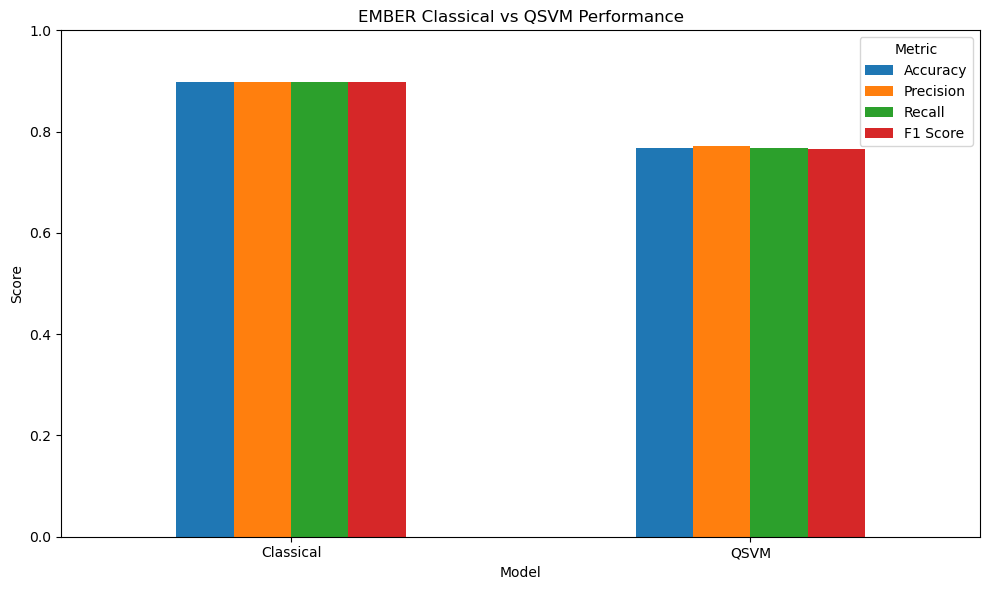

In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("EMBER Classical vs QSVM Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

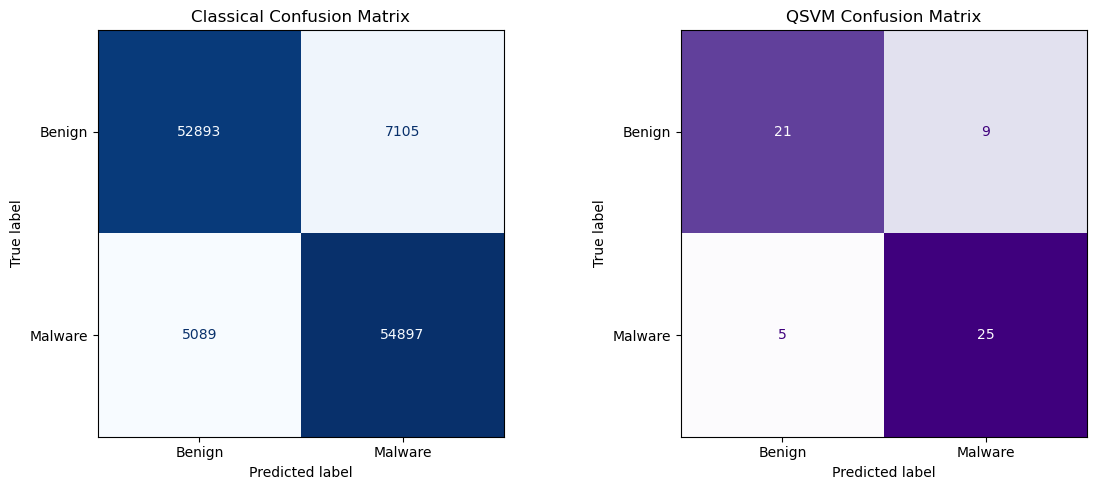

In [4]:
classical_predictions = pd.read_csv(
    out_dir + r"\ember_classical_predictions.csv"
)

qsvm_predictions = pd.read_csv(
    out_dir + r"\ember_qsvm_predictions.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_classical = confusion_matrix(
    classical_predictions["Actual"],
    classical_predictions["Predicted"]
)

ConfusionMatrixDisplay(
    cm_classical,
    display_labels=["Benign", "Malware"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Classical Confusion Matrix")

cm_qsvm = confusion_matrix(
    qsvm_predictions["Actual"],
    qsvm_predictions["Predicted"]
)

ConfusionMatrixDisplay(
    cm_qsvm,
    display_labels=["Benign", "Malware"]
).plot(
    ax=axes[1],
    cmap="Purples",
    colorbar=False
)

axes[1].set_title("QSVM Confusion Matrix")

plt.tight_layout()
plt.show()